# CDGS production

These examples are related to the production of a Common Decay Gamma Source (CDGS) file starting from a cloud point (often coming from a flunet calculation)

## The interpolation

The starting point to create CDGS is often a cloud point (representing the centroids of a mesh)
that have information on the specific atomic density of each radio-isotope of interest and volume
in each cell. This information needs to be translated into a structured mesh.

To do so, there are two main thing to decide:
- the bin sizes
- how to interpolate the cloud point on the new mesh

These two main points are controlled respectively by the
``InterpolationKernel`` and ``MeshDefinition`` object families

### MeshDefinition

There are three concrete `MeshDefinition` children, each controlling how the structured grid is built from the cloud point:

| Class | What you provide | How the voxel size is determined |
|---|---|---|
| `MeshByAverageDistance` | `factor` (float) | Average nearest-neighbour distance × factor |
| `MeshByBinSize` | `bin_size` (x, y, z tuple) | Fixed bin size you specify directly |
| `MeshByNumberOfVoxels` | `n_voxels` (nx, ny, nz tuple) + bounding box | bbox extent / n_voxels per axis |

All three accept an optional `bbox` dict (`x_min`, `x_max`, `y_min`, `y_max`, `z_min`, `z_max`) to override the automatic bounding box.

The following shows an example of these definition can change significantly the mesh that will be produced
inside the ``CDGS`` object

In [1]:
import pandas as pd
import pyvista as pv
from f4enix.output.cdgs import MeshByAverageDistance, MeshByBinSize, MeshByNumberOfVoxels

# Read the same cloud point used in the rest of the notebook
source_activity = pd.read_csv('activity_example1.csv')
source_activity.columns = source_activity.columns.str.strip()
coords = source_activity[['x', 'y', 'z']].values

bbox = {
    "x_min": coords[:, 0].min(),
    "x_max": coords[:, 0].max(),
    "y_min": coords[:, 1].min(),
    "y_max": coords[:, 1].max(),
    "z_min": coords[:, 2].min(),
    "z_max": coords[:, 2].max(),
}

definitions = {
    "MeshByAverageDistance(factor=10)": (MeshByAverageDistance(factor=10)),
    "MeshByBinSize(bin_size=(50, 60, 50))": (MeshByBinSize(bin_size=(50, 60, 50))),
    "MeshByNumberOfVoxels(n_voxels=(10,5,10))": (MeshByNumberOfVoxels(n_voxels=(10, 5, 10), bbox=bbox)),
}

for mesh_name, mesh_def in definitions.items():
    print(f"\nBuilding mesh: {mesh_name}")
    mesh = mesh_def._build_grid(coords)
    print(mesh)



Building mesh: MeshByAverageDistance(factor=10)
StructuredGrid (0x1798556e560)
  N Cells:      968
  N Points:     1587
  X Bounds:     -7.447e-02, 7.447e-02
  Y Bounds:     -2.626e-01, -2.508e-01
  Z Bounds:     7.896e-01, 9.384e-01
  Dimensions:   23, 3, 23
  N Arrays:     0

Building mesh: MeshByBinSize(bin_size=(50, 60, 50))
StructuredGrid (0x1798556dd20)
  N Cells:      1
  N Points:     8
  X Bounds:     -2.507e+01, 2.507e+01
  Y Bounds:     -3.026e+01, 2.975e+01
  Z Bounds:     -2.421e+01, 2.594e+01
  Dimensions:   2, 2, 2
  N Arrays:     0

Building mesh: MeshByNumberOfVoxels(n_voxels=(10,5,10))
StructuredGrid (0x1798556dc60)
  N Cells:      500
  N Points:     726
  X Bounds:     -7.111e-02, 7.111e-02
  Y Bounds:     -2.592e-01, -2.541e-01
  Z Bounds:     7.930e-01, 9.350e-01
  Dimensions:   11, 6, 11
  N Arrays:     0


### InterpolationKernel

There are three concrete `InterpolationKernel` children. `SphereKernel` and `DistanceKernel` share the same **neighbour search** strategy (a sphere around each source point) but differ in **how activity is distributed** to the neighbours. `KNearestKernel` instead searches for a fixed number of nearest neighbours:

| Class | Key parameter(s) | Neighbour search | Activity distribution |
|---|---|---|---|
| `SphereKernel` | `radius` **or** `n_voxels` | sphere of fixed `radius`, or `n_voxels × voxel_size` | uniform — each neighbour receives an equal share |
| `DistanceKernel` | `radius` **or** `n_voxels` | same as `SphereKernel` | inverse-distance weighted — closer neighbours receive proportionally more |
| `KNearestKernel` | `k` | the `k` nearest destination points, regardless of distance | inverse-distance weighted, same as `DistanceKernel` |

It is important to notice that all these methods will always conserve locally (how local depends on the interpolation sphere/neighbourhood dimension) and globally the total activity.

`n_voxels` is the more practical option for `SphereKernel`/`DistanceKernel`: the search radius is set automatically as a multiple of the mesh voxel size, so it adapts when you change the `MeshDefinition`.

> **Note — for maximum speed, prefer `KNearestKernel`.** `SphereKernel` and `DistanceKernel` search a variable number of neighbours per source point, so `CDGS.from_cloud_point` must distribute the activity with a plain Python loop over every cloud point. `KNearestKernel` always returns exactly `k` neighbours per point, which makes the neighbour index array a dense, rectangular matrix instead of a ragged one. This lets `from_cloud_point` distribute the activity for **all** source points in one vectorized numpy operation instead of looping in Python, which is dramatically faster on large cloud points (millions of points): a benchmark on a ~6.3M-point cloud went from over 12 minutes with `DistanceKernel` to under 15 seconds with `KNearestKernel`.

The following example show the effect of using different radius searches on the final interpolated results.

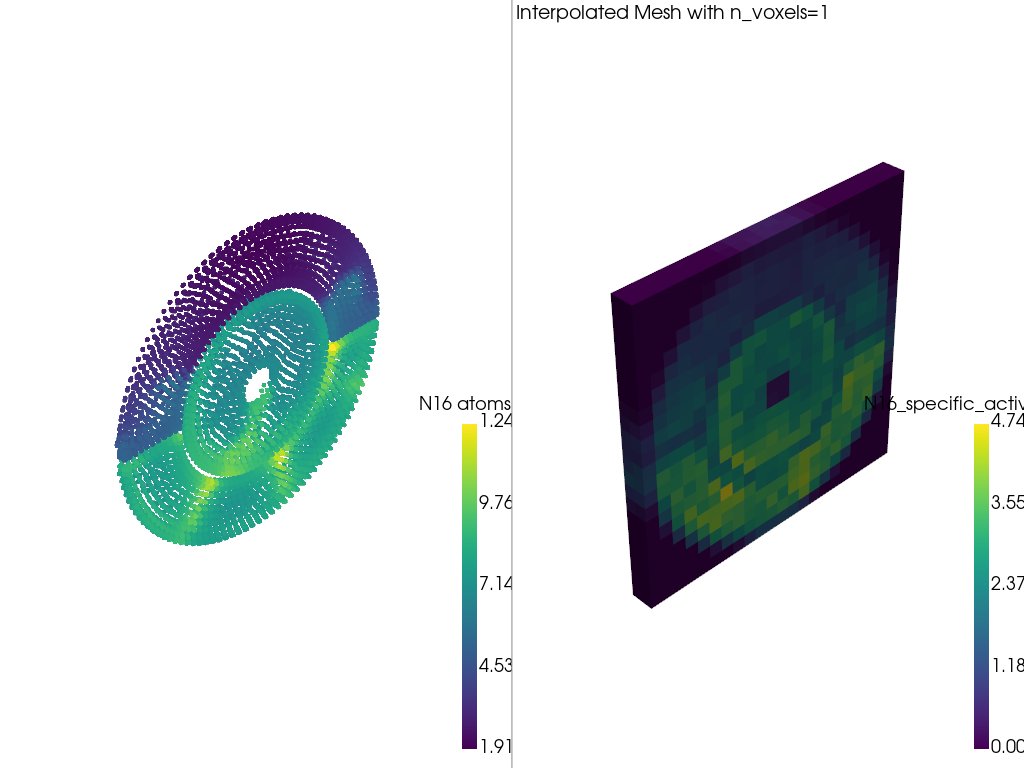

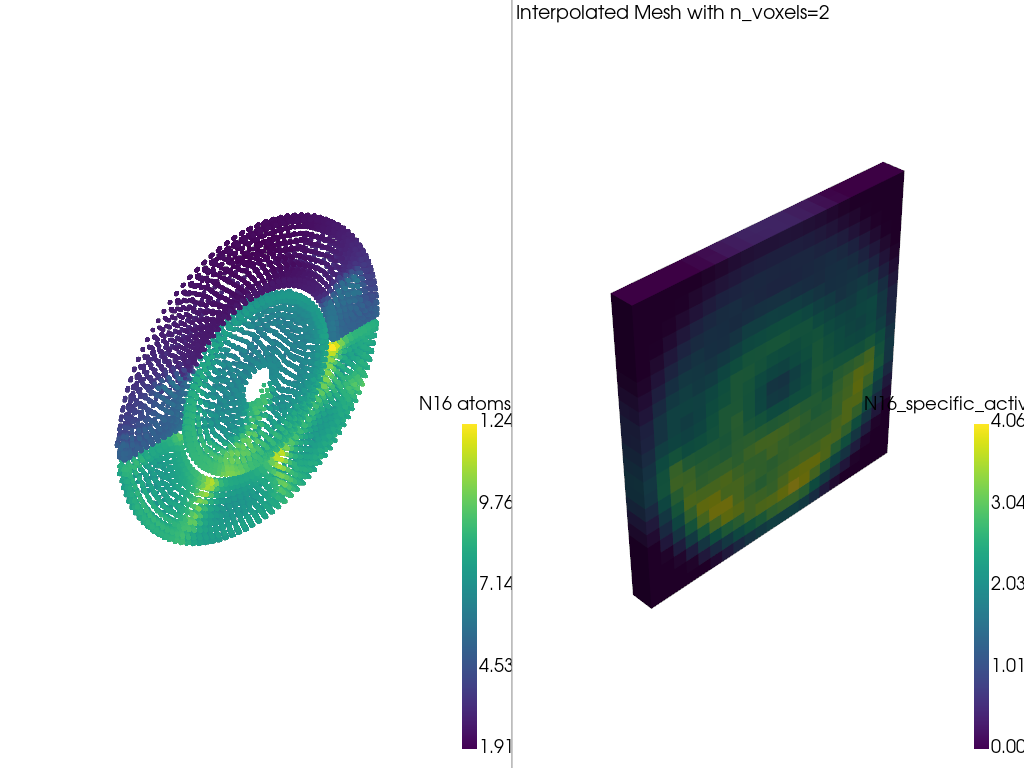

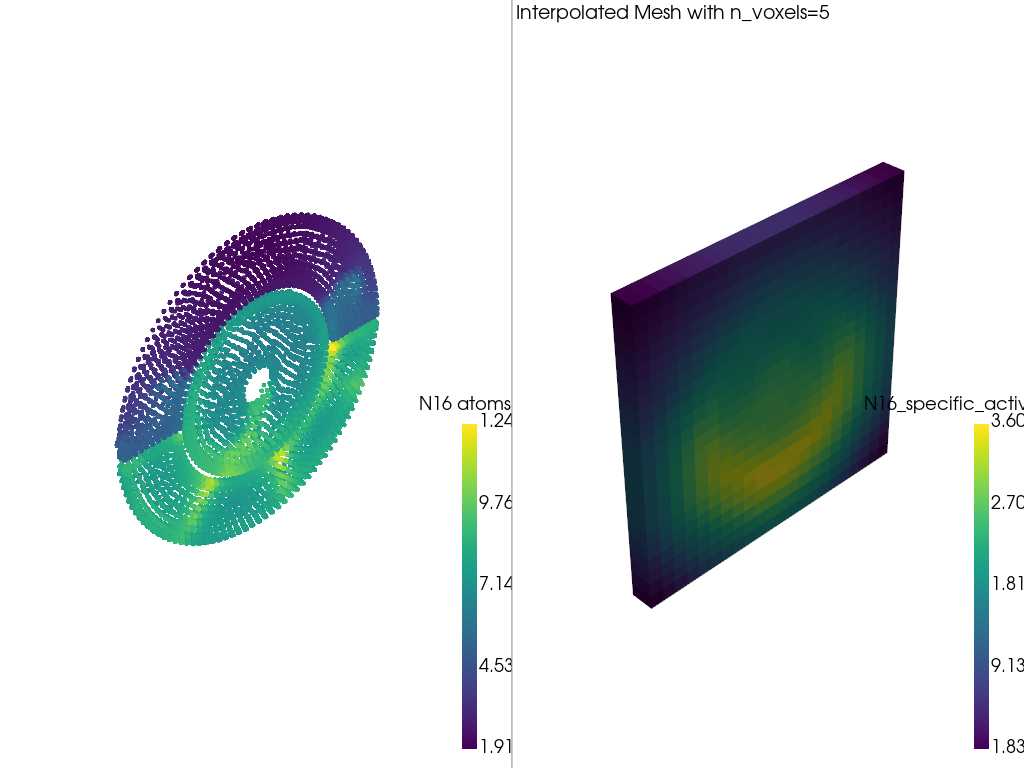

In [2]:
import pandas as pd
from f4enix.output.cdgs import CDGS, SphereKernel, MeshByAverageDistance
from f4enix.output.cdgs.cdgs import ACTIVITY_TAG

source_activity = pd.read_csv('activity_example1.csv')
source_activity.columns = source_activity.columns.str.strip()  # Strip whitespace from column names
cloudpoint = pv.PolyData(source_activity[['x', 'y', 'z']].values)
cloudpoint['N16 atoms/m3'] = source_activity['n16'].values

for n_voxel in [1, 2, 5]:
    cdgs = CDGS.from_cloud_point(
        'activity_example1.csv',
        {"N16": "n16"},
        interpolation_kernel=SphereKernel(n_voxels=n_voxel),
        mesh_definition=MeshByAverageDistance(factor=10),
        col_names={"x": "x", "y": "y", "z": "z", "vol": "cell-volume"}
        )

    interpolated_mesh = cdgs.mesh

    # plotting
    plotter = pv.Plotter(shape=(1, 2))

    plotter.subplot(0, 0)
    plotter.add_mesh(
        cloudpoint,
        scalars='N16 atoms/m3',
        scalar_bar_args={"vertical": True},
    )


    plotter.subplot(0, 1)
    plotter.add_mesh(
        cdgs.mesh,
        scalars=f'N16{ACTIVITY_TAG}',
        scalar_bar_args={"vertical": True},
    )
    plotter.add_text(f"Interpolated Mesh with n_voxels={n_voxel}", font_size=12)

    plotter.show(jupyter_backend="static")


The `KNearestKernel` is used the same way, but the parameter that controls the neighbourhood size is `k` (the number of nearest destination points) instead of `n_voxels`/`radius`.

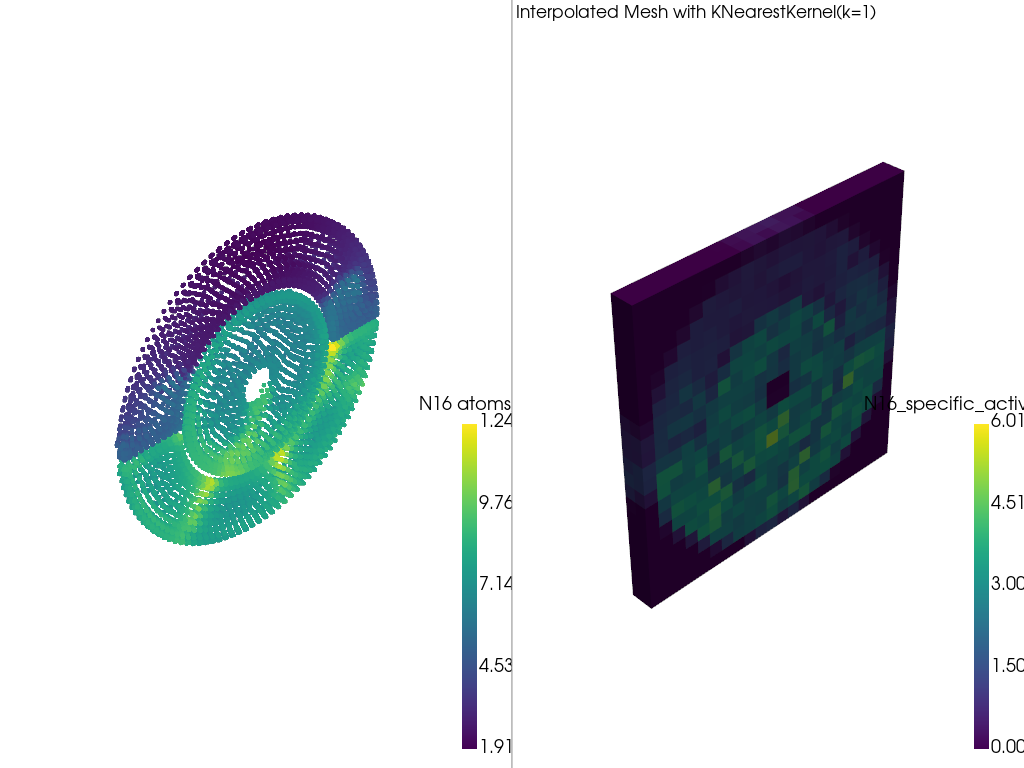

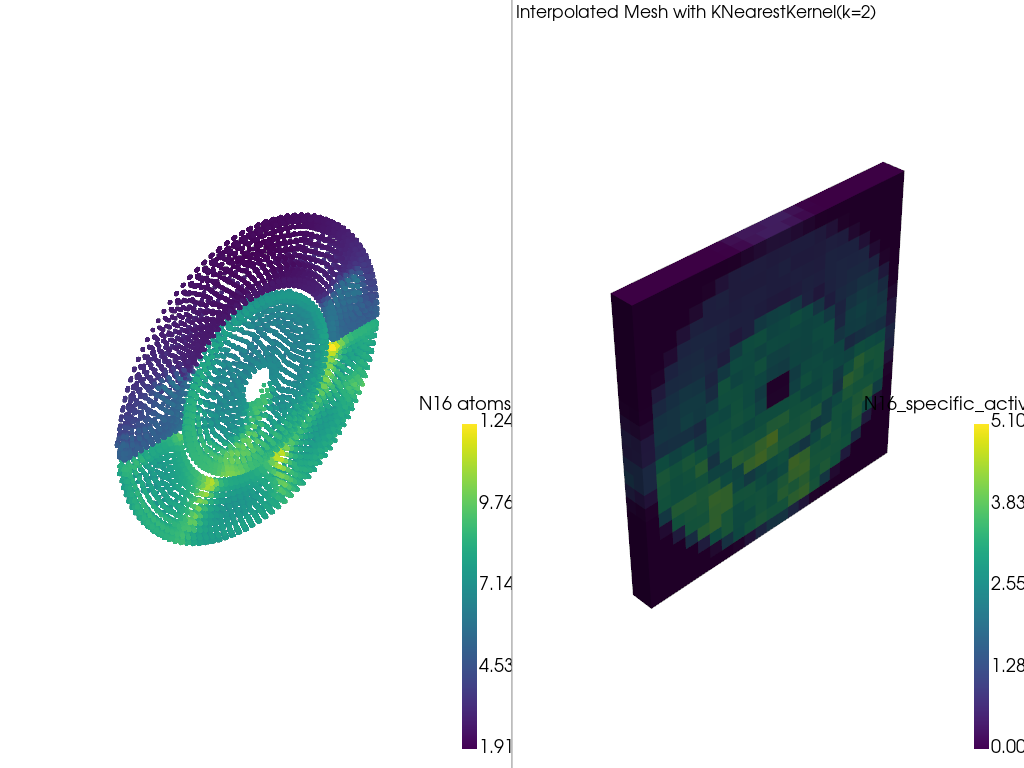

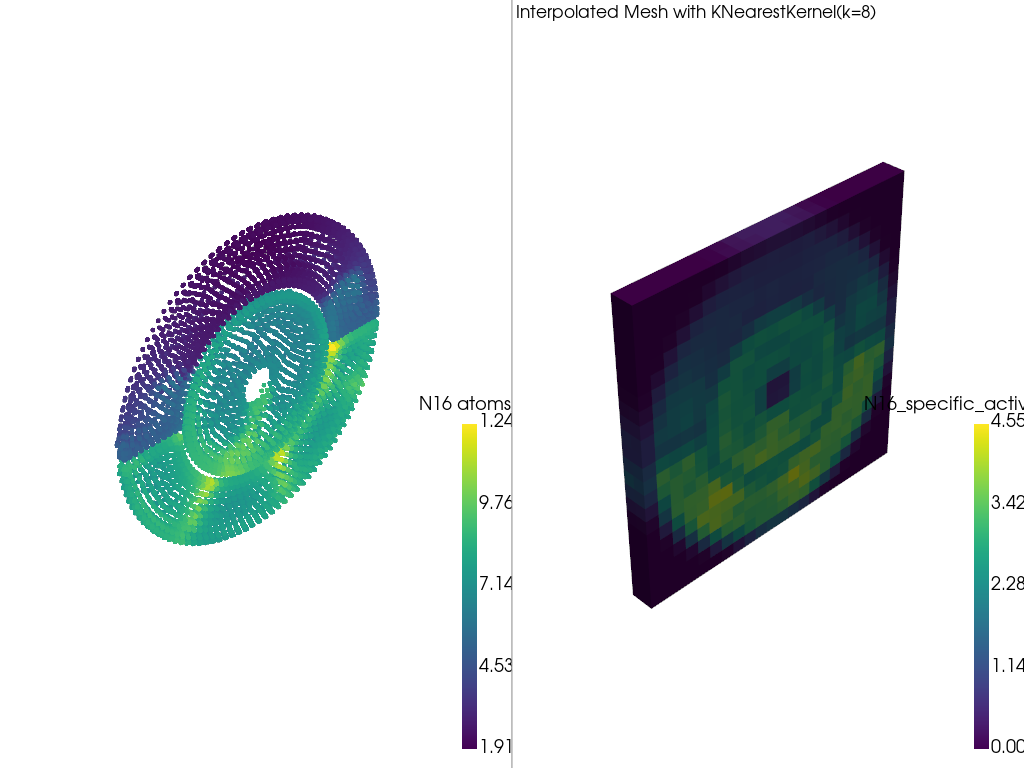

In [3]:
from f4enix.output.cdgs import KNearestKernel

for k in [1, 2, 8]:
    cdgs = CDGS.from_cloud_point(
        'activity_example1.csv',
        {"N16": "n16"},
        interpolation_kernel=KNearestKernel(k=k),
        mesh_definition=MeshByAverageDistance(factor=10),
        col_names={"x": "x", "y": "y", "z": "z", "vol": "cell-volume"}
        )

    interpolated_mesh = cdgs.mesh

    # plotting
    plotter = pv.Plotter(shape=(1, 2))

    plotter.subplot(0, 0)
    plotter.add_mesh(
        cloudpoint,
        scalars='N16 atoms/m3',
        scalar_bar_args={"vertical": True},
    )

    plotter.subplot(0, 1)
    plotter.add_mesh(
        cdgs.mesh,
        scalars=f'N16{ACTIVITY_TAG}',
        scalar_bar_args={"vertical": True},
    )
    plotter.add_text(f"Interpolated Mesh with KNearestKernel(k={k})", font_size=12)

    plotter.show(jupyter_backend="static")


## The CDGS object

As seen above, the creation of a regular mesh and interpolation happens directly inside the
``CDGS`` object. The data is stored in a pyvista grid and can be further manipulated if needed. In addition to the interpolated atomic density, also the activity is computed and stored in the mesh.

In [4]:
# Create a CDGS object from the cloud point data
cdgs = CDGS.from_cloud_point(
    'activity_example1.csv',
    {"N16": "n16", "O19": "o19"},
    interpolation_kernel=SphereKernel(n_voxels=1),
    mesh_definition=MeshByAverageDistance(factor=10),
    col_names={"x": "x", "y": "y", "z": "z", "vol": "cell-volume"},
    e_bins=None, # If energy bins are not set, emission lines will be used
    particle="gamma" # either gamma or neutron
)
cdgs

CDGS(mesh=StructuredGrid (0x179856af760)
  N Cells:      968
  N Points:     1587
  X Bounds:     -7.447e-02, 7.447e-02
  Y Bounds:     -2.626e-01, -2.508e-01
  Z Bounds:     7.896e-01, 9.384e-01
  Dimensions:   23, 3, 23
  N Arrays:     6, energy_type=CDGS_ENERGY_TYPE.LINE, isotopes=['N16', 'O19'], particle=gamma, cooling_time=0.0)

In [5]:
# Info is stored in a pyvista object
print(cdgs.mesh.array_names)
cdgs.mesh

['N16_specific_activity [Bq/m3]', 'N16_specific_atom_density [atom/m3]', 'O19_specific_activity [Bq/m3]', 'O19_specific_atom_density [atom/m3]', 'N16_intensity [ph/s]', 'O19_intensity [ph/s]']


StructuredGrid (0x179856af760)
  N Cells:      968
  N Points:     1587
  X Bounds:     -7.447e-02, 7.447e-02
  Y Bounds:     -2.626e-01, -2.508e-01
  Z Bounds:     7.896e-01, 9.384e-01
  Dimensions:   23, 3, 23
  N Arrays:     6

In [6]:
# Emission lines are availables also for the combination of radioisotopes
cdgs.all_df

,lines,intensities,isotope
10,109900.0,0.030000,O19
11,197200.0,0.958000,O19
0,986500.0,0.000035,N16
12,1357000.0,0.541000,O19
13,1444000.0,0.030000,O19
14,1554000.0,0.014000,O19
15,1597000.0,0.000300,O19
1,1755000.0,0.001400,N16
2,1954800.0,0.000400,N16
16,2582000.0,0.000300,O19


In [7]:
# Or singularly for each isotope
for isotope, values in cdgs.isotopes.items():
    print(f"\nIsotope: {isotope}")
    print(values)


Isotope: N16
{'lines': array([ 986500., 1755000., 1954800., 2741500., 2822500., 6048200.,
       6129170., 6915500., 7115150., 8869200.]), 'intensities': array([3.50000048e-05, 1.39999744e-03, 3.99999760e-04, 8.39999840e-03,
       1.29999664e-05, 1.29999664e-04, 6.88000000e-01, 3.99999760e-04,
       4.99999872e-02, 7.99999520e-04])}

Isotope: O19
{'lines': array([ 109900.,  197200., 1357000., 1444000., 1554000., 1597000.,
       2582000., 4179000.]), 'intensities': array([2.99999616e-02, 9.58000000e-01, 5.40999844e-01, 2.99999616e-02,
       1.40000204e-02, 2.99999616e-04, 2.99999616e-04, 1.29999642e-03])}


Cooling time can be set by the user and will update the values in the CDGS. If a new cooling time
is set, the decay of radioisotopes is always computed starting from shutdown activity

In [8]:
print('Cooling time set to 0 seconds by default:')
print(f'{cdgs.get_total_intensity("all"):.2e} photons/s')

cdgs.cooling_time = 100  # Set cooling time to 100 seconds

print('Cooling time set to 100 seconds:')
print(f'{cdgs.get_total_intensity("all"):.2e} photons/s')


Cooling time set to 0 seconds by default:
4.09e+06 photons/s
Cooling time set to 100 seconds:
4.42e+04 photons/s


Helper methods are provided to dump the data either in .vtk or .cdgs (ASCII) format.

In [9]:
import tempfile
tmp_dir = tempfile.gettempdir()

cdgs.to_vtk(tmp_dir + "/cdgs_export.vtk")
cdgs.to_cdgs(tmp_dir + "/cdgs_export.cdgs", 'N16')
# Export a source that combines all isotopes in the CDGS object
cdgs.to_cdgs(tmp_dir + "/cdgs_export_all.cdgs", 'all')